# Supercell Observation Route Optimization
## Concepts, Patterns, and Three Levels of Optimization

### Problem Overview
Given a set of supercells (circular TPV or elliptical Jet Deformation),
fly from a base airport, observe as many supercells as possible, return to base.

### Three Optimization Levels
| Version | Fixed | Optimize | Problem Type |
|---------|-------|----------|--------------|
| **v1 (demo)** | theta, m, s, L all fixed | visit order + which cells | Standard Orienteering |
| **v2 (medium)** | m, s, L fixed | visit order + **theta** | Orienteering + direction |
| **v3 (full)** | nothing fixed | order + theta + m + s + L | Full combinatorial |

### Key Insight
Once all parameters (including theta) are fixed for a supercell,
**all waypoints and entry/exit points are fully determined**.
This means the inter-cell travel cost is computable given the assignment of thetas and visit order.


In [1]:
import os, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
from itertools import permutations

os.makedirs('figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

def uvec(a): return np.array([np.cos(a), np.sin(a)])

print("Ready.")


Ready.


---
## 1. Data Structures

All supercell parameters are **given as input** to the optimization.
What differs across the three problem versions is which of these are treated as optimization variables.


In [2]:
@dataclass
class CircularSupercell:
    """
    Circular supercell (TPV pattern).
    Observation pattern: 2 orthogonal legs crossing at anchor q_k.

    GIVEN parameters (always fixed as input):
      center : q_k = (x, y)  -- anchor point
      radius : R              -- strongest gradient zone radius (km); NOT leg endpoint
      L      : half-length of each leg, i.e. max_reach (km); L > R
      weight : w_k            -- scientific priority

    v1: theta is also fixed externally
    v2: theta is an optimization variable (discrete set)
    v3: theta AND L are optimization variables
    """
    center: np.ndarray
    radius: float        # gradient zone radius (visualization only)
    L: float             # leg half-length = max_reach (L > radius)
    weight: float = 1.0
    name: str = "TPV"

    def leg_endpoints(self, theta: float) -> List[Tuple[np.ndarray, np.ndarray]]:
        """Given theta, return the 4 waypoints as 2 legs.
        These are FULLY DETERMINED once theta is chosen."""
        q = self.center
        leg1 = (q - self.L * uvec(theta),     q + self.L * uvec(theta))
        leg2 = (q - self.L * uvec(theta+np.pi/2), q + self.L * uvec(theta+np.pi/2))
        return [leg1, leg2]

    def entry_exit_points(self, theta: float) -> List[np.ndarray]:
        """All 4 candidate entry/exit points for this cell at direction theta."""
        q = self.center
        return [q - self.L * uvec(theta),     q + self.L * uvec(theta),
                q - self.L * uvec(theta+np.pi/2), q + self.L * uvec(theta+np.pi/2)]


@dataclass
class EllipticalSupercell:
    """
    Elliptical supercell (Jet Deformation pattern).
    Observation pattern: m parallel legs, spacing s, truncated at ellipse boundary.
    Legs are connected in boustrophedon (lawnmower) order.

    GIVEN parameters (always fixed as input):
      center    : q_k = (x, y)
      a, b      : semi-major / semi-minor axes (km)
      phi       : major axis orientation (radians)
      m         : number of parallel legs (e.g. 3-7)
      s         : spacing between parallel legs (km)
      weight    : w_k

    v1: theta is also fixed externally
    v2: theta is an optimization variable (discrete set)
    v3: theta AND m, s are optimization variables
    """
    center: np.ndarray
    a: float             # semi-major axis
    b: float             # semi-minor axis
    phi: float           # major axis orientation (radians)
    m: int               # number of parallel legs
    s: float             # leg spacing (km)
    weight: float = 1.0
    name: str = "JetDef"

    def _ellipse_intersect(self, line_center, theta):
        """Find intersection of line (through line_center, direction theta) with this ellipse."""
        cp, sp = np.cos(self.phi), np.sin(self.phi)
        d = uvec(theta)
        dl = np.array([d[0]*cp+d[1]*sp, -d[0]*sp+d[1]*cp])
        lc = line_center - self.center
        ll = np.array([lc[0]*cp+lc[1]*sp, -lc[0]*sp+lc[1]*cp])
        A = (dl[0]/self.a)**2 + (dl[1]/self.b)**2
        B = 2*(ll[0]*dl[0]/self.a**2 + ll[1]*dl[1]/self.b**2)
        C = (ll[0]/self.a)**2 + (ll[1]/self.b)**2 - 1
        disc = B**2 - 4*A*C
        if disc < 0: return None
        t1, t2 = (-B-np.sqrt(disc))/(2*A), (-B+np.sqrt(disc))/(2*A)
        return line_center + t1*d, line_center + t2*d

    def leg_endpoints(self, theta: float) -> List[Tuple[np.ndarray, np.ndarray]]:
        """Given theta, return m leg endpoints (truncated at ellipse boundary).
        FULLY DETERMINED once theta is chosen."""
        n = uvec(theta + np.pi/2)
        legs = []
        for i in range(self.m):
            offset = self.s * (i - (self.m-1)/2.0)
            result = self._ellipse_intersect(self.center + offset*n, theta)
            if result is not None:
                legs.append(result)
        return legs

    def boustrophedon_wpts(self, theta: float) -> List[np.ndarray]:
        """Full ordered waypoint list for lawnmower scan at direction theta."""
        legs = self.leg_endpoints(theta)
        wpts = []
        for i, (ps, pe) in enumerate(legs):
            wpts.extend([ps.copy(), pe.copy()] if i%2==0 else [pe.copy(), ps.copy()])
        return wpts

    def entry_exit_points(self, theta: float) -> Tuple[np.ndarray, np.ndarray]:
        """Entry point = first waypoint, exit point = last waypoint of boustrophedon."""
        wpts = self.boustrophedon_wpts(theta)
        if not wpts: return None, None
        return wpts[0], wpts[-1]


print("Data structures defined.")
print()
print("Key design: leg_endpoints(theta) and entry_exit_points(theta) are")
print("FULLY DETERMINED given theta -- no other free parameters remain.")


Data structures defined.

Key design: leg_endpoints(theta) and entry_exit_points(theta) are
FULLY DETERMINED given theta -- no other free parameters remain.


---
## 2. Score Functions

### Circular Score
Since L > radius, legs always pass through the entire gradient zone.
When a cell is visited, both legs are flown -> **Score = 1.0** (binary: visit or not).

### Elliptical Score
Two components:
- **Width Coverage**: do m parallel legs span the full ellipse width perpendicular to theta?
  - Span = (m-1)*s; Ellipse width in normal direction = W_perp(theta)
- **Direction Alignment**: is theta well-aligned with the major axis (phi)?
  - Center leg length / 2a

**The direction theta critically affects the ellipse score**, which is why v2/v3 optimize it.


In [3]:
def score_circular(cell: CircularSupercell, theta: float, visited: bool = True) -> float:
    """Score = 1 if visited (both legs always flown), 0 if not."""
    return 1.0 if visited else 0.0

def score_elliptical(cell: EllipticalSupercell, theta: float, beta: float = 0.6) -> dict:
    """Elliptical supercell score."""
    delta = theta - cell.phi
    # Width coverage
    W_perp = 2*np.sqrt(cell.a**2*np.sin(delta)**2 + cell.b**2*np.cos(delta)**2)
    width_cov = min((cell.m-1)*cell.s, W_perp) / W_perp
    # Direction alignment
    L_center = 2*np.sqrt(cell.a**2*np.cos(delta)**2 + cell.b**2*np.sin(delta)**2)
    dir_align = L_center / (2*cell.a)
    total = beta*width_cov + (1-beta)*dir_align
    return {'total': total, 'width_cov': width_cov, 'dir_align': dir_align, 'W_perp': W_perp}

def total_score(cells_visited, thetas):
    """Weighted sum of scores for all visited cells."""
    s = 0
    for cell, th in zip(cells_visited, thetas):
        if isinstance(cell, CircularSupercell):
            s += cell.weight * score_circular(cell, th)
        else:
            s += cell.weight * score_elliptical(cell, th)['total']
    return s

# ── Quick demo ──
c = CircularSupercell(np.array([0,0]), radius=60, L=110, weight=1.5, name="TPV-A")
e = EllipticalSupercell(np.array([0,0]), a=90, b=35, phi=np.radians(40),
                         m=5, s=16, weight=2.0, name="Jet-B")

print("Circular cell: score =", score_circular(c, theta=np.radians(45)))
print("  (always 1.0 regardless of theta -- circle is symmetric)")
print()
for th in [40, 70, 130]:
    sc = score_elliptical(e, np.radians(th))
    print(f"Elliptical cell: theta={th:3d} deg -> score={sc['total']:.3f}"
          f"  (width_cov={sc['width_cov']:.2f}, dir_align={sc['dir_align']:.2f})")


Circular cell: score = 1.0
  (always 1.0 regardless of theta -- circle is symmetric)

Elliptical cell: theta= 40 deg -> score=0.949  (width_cov=0.91, dir_align=1.00)
Elliptical cell: theta= 70 deg -> score=0.709  (width_cov=0.59, dir_align=0.89)
Elliptical cell: theta=130 deg -> score=0.369  (width_cov=0.36, dir_align=0.39)


---
## 3. Pattern Visualization

Showing that once theta is chosen, **all waypoints are fully determined**.


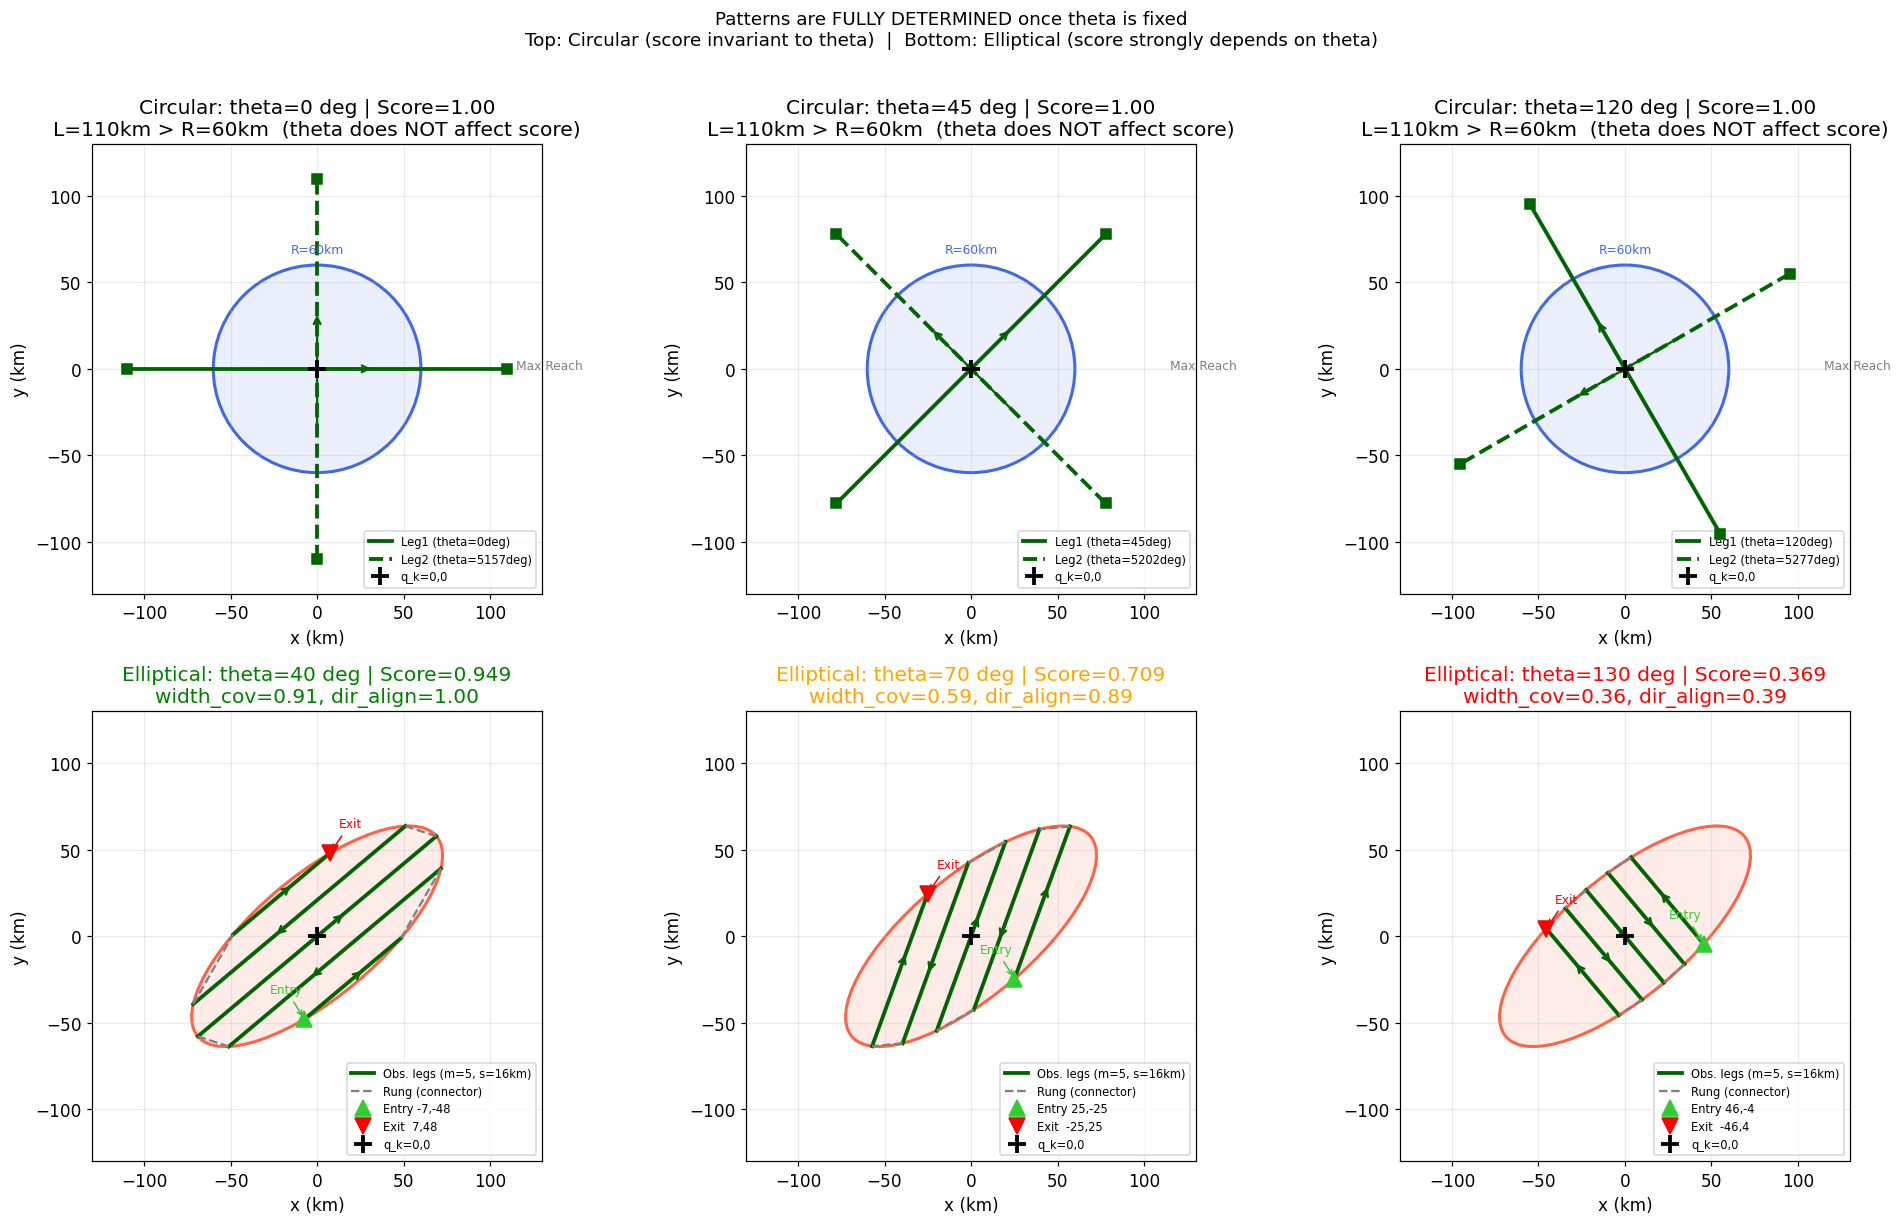

In [4]:
def draw_cell(ax, cell, theta, color_leg='darkgreen', show_entry_exit=True):
    q = cell.center

    if isinstance(cell, CircularSupercell):
        # gradient zone circle
        ax.add_patch(plt.Circle(q, cell.radius, color='royalblue', alpha=0.10))
        ax.add_patch(plt.Circle(q, cell.radius, fill=False, edgecolor='royalblue', lw=2))
        ax.text(q[0], q[1]+cell.radius+7, f'R={cell.radius:.0f}km',
                ha='center', fontsize=8, color='royalblue')
        legs = cell.leg_endpoints(theta)
        for i, (ps, pe) in enumerate(legs):
            ax.plot([ps[0],pe[0]], [ps[1],pe[1]], color=color_leg,
                    lw=2.5, ls='-' if i==0 else '--',
                    label=f'Leg{i+1} (theta={np.degrees(theta+i*90):.0f}deg)' if i<2 else '_')
            mid = (ps+pe)/2; dv = pe-ps
            ax.annotate('', xy=mid+0.15*dv, xytext=mid-0.15*dv,
                        arrowprops=dict(arrowstyle='->', color=color_leg, lw=1.5))
        all_pts = [ps for ps,pe in legs] + [pe for ps,pe in legs]
        if show_entry_exit:
            for pt in all_pts:
                ax.plot(*pt, 's', color=color_leg, ms=7, zorder=6)
            ax.text(q[0]+cell.L+5, q[1], 'Max Reach', fontsize=8, color='gray')

    else:  # Elliptical
        ax.add_patch(Ellipse(q, 2*cell.a, 2*cell.b, angle=np.degrees(cell.phi),
                             color='tomato', alpha=0.12))
        ax.add_patch(Ellipse(q, 2*cell.a, 2*cell.b, angle=np.degrees(cell.phi),
                             fill=False, edgecolor='tomato', lw=2))
        legs = cell.leg_endpoints(theta)
        wpts = cell.boustrophedon_wpts(theta)
        for i, (ps, pe) in enumerate(legs):
            ax.plot([ps[0],pe[0]], [ps[1],pe[1]], color=color_leg, lw=2.5,
                    label=f'Obs. legs (m={cell.m}, s={cell.s:.0f}km)' if i==0 else '_nolegend_')
            fly_s, fly_e = (ps,pe) if i%2==0 else (pe,ps)
            mid=(fly_s+fly_e)/2; dv=fly_e-fly_s
            ax.annotate('', xy=mid+0.12*dv, xytext=mid-0.12*dv,
                        arrowprops=dict(arrowstyle='->', color=color_leg, lw=1.5))
        for i in range(len(wpts)-1):
            if i%2==1:
                ax.plot([wpts[i][0],wpts[i+1][0]], [wpts[i][1],wpts[i+1][1]],
                        color='gray', lw=1.5, ls='--',
                        label='Rung (connector)' if i==1 else '_nolegend_')
        if show_entry_exit and wpts:
            entry, exitt = wpts[0], wpts[-1]
            ax.plot(*entry, '^', color='limegreen', ms=10, zorder=7,
                    label=f'Entry {entry[0]:.0f},{entry[1]:.0f}')
            ax.plot(*exitt, 'v', color='red', ms=10, zorder=7,
                    label=f'Exit  {exitt[0]:.0f},{exitt[1]:.0f}')

    ax.plot(*q, 'k+', ms=12, mew=2.5, zorder=8, label=f'q_k={q[0]:.0f},{q[1]:.0f}')


# ── Demo scene ──
c_demo = CircularSupercell(np.array([0,0]), radius=60, L=110, weight=1.5, name="TPV-A")
e_demo = EllipticalSupercell(np.array([0,0]), a=90, b=35, phi=np.radians(40),
                              m=5, s=16, weight=2.0, name="Jet-B")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Row 0: Circular at 3 different theta
for ax, th in zip(axes[0], [0, 45, 120]):
    draw_cell(ax, c_demo, np.radians(th))
    pad=130
    ax.set_xlim(-pad,pad); ax.set_ylim(-pad,pad); ax.set_aspect('equal')
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.grid(True,alpha=0.25); ax.legend(fontsize=7.5, loc='lower right')
    sc = score_circular(c_demo, np.radians(th))
    ax.set_title(f"Circular: theta={th} deg | Score={sc:.2f}\n"
                 f"L={c_demo.L:.0f}km > R={c_demo.radius:.0f}km  (theta does NOT affect score)")

# Row 1: Elliptical at 3 different theta
for ax, th in zip(axes[1], [40, 70, 130]):
    draw_cell(ax, e_demo, np.radians(th))
    pad=130
    ax.set_xlim(-pad,pad); ax.set_ylim(-pad,pad); ax.set_aspect('equal')
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.grid(True,alpha=0.25); ax.legend(fontsize=7.5, loc='lower right')
    sc = score_elliptical(e_demo, np.radians(th))
    col = 'green' if sc['total']>0.8 else 'orange' if sc['total']>0.6 else 'red'
    ax.set_title(f"Elliptical: theta={th} deg | Score={sc['total']:.3f}\n"
                 f"width_cov={sc['width_cov']:.2f}, dir_align={sc['dir_align']:.2f}", color=col)
    # mark entry/exit
    entry, exitt = e_demo.entry_exit_points(np.radians(th))
    if entry is not None:
        ax.annotate('Entry', xy=entry, xytext=entry+np.array([-20,15]), fontsize=8,
                    color='limegreen', arrowprops=dict(arrowstyle='->', color='limegreen'))
        ax.annotate('Exit', xy=exitt, xytext=exitt+np.array([5,15]), fontsize=8,
                    color='red', arrowprops=dict(arrowstyle='->', color='red'))

plt.suptitle("Patterns are FULLY DETERMINED once theta is fixed\n"
             "Top: Circular (score invariant to theta)  |  "
             "Bottom: Elliptical (score strongly depends on theta)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures/pattern_both_types.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 4. Three Optimization Problem Versions

### v1 (Simplified Demo): All parameters fixed, optimize visit order only

Decision variables:
- $x_k \in \{0,1\}$: visit cell $k$ or not
- $\sigma$: permutation of visited cells (order)

Since theta (and L/m/s) are fixed, all waypoints and inter-cell distances are **precomputed**.
The problem reduces to a standard **Orienteering Problem (OP)**:
$$\max_{x, \sigma} \sum_k w_k \cdot x_k \quad \text{s.t.} \quad D(\sigma) \leq B$$

### v2 (Medium): L/m/s fixed, optimize order + theta per cell

Decision variables: $x_k$, $\sigma$, and $\theta_k \in \Theta = \{0°, 15°, ..., 165°\}$

For circular cells: adding theta to the search has no score benefit (circle symmetric),
but **affects inter-cell travel cost** (entry/exit point changes with theta).
For elliptical cells: theta directly affects both score AND inter-cell cost.

### v3 (Full): Everything is an optimization variable
Decision variables: $x_k$, $\sigma$, $\theta_k$, $L_k$ (circle), $m_k$, $s_k$ (ellipse)


In [5]:
# ══════════════════════════════════════════════════════════════
# V1 DEMO: All params fixed. Only optimize visit order.
# Brute-force for small N (will be replaced by MILP in next notebook)
# ══════════════════════════════════════════════════════════════

BASE = np.array([0.0, 0.0])
BUDGET_KM = 1400.0

# Fixed thetas (v1: these are given, not optimized)
THETAS_FIXED = {
    'TPV-A':  np.radians(30),   # arbitrary fixed direction
    'TPV-B':  np.radians(75),
    'Jet-C':  np.radians(35),   # close to phi -> good score
    'Jet-D':  np.radians(80),   # off-axis -> lower score
}

# Define 4 supercells
cells_v1 = [
    CircularSupercell(np.array([200, 180]), radius=55, L=100, weight=1.5, name='TPV-A'),
    CircularSupercell(np.array([350,  60]), radius=50, L=90,  weight=1.2, name='TPV-B'),
    EllipticalSupercell(np.array([480, 200]), a=80, b=30, phi=np.radians(35),
                        m=5, s=15, weight=2.0, name='Jet-C'),
    EllipticalSupercell(np.array([150, 320]), a=70, b=28, phi=np.radians(20),
                        m=4, s=14, weight=1.8, name='Jet-D'),
]

def inter_cell_distance(cell_from, theta_from, cell_to, theta_to):
    """
    Minimum distance from exit of cell_from (at theta_from)
    to entry of cell_to (at theta_to).
    For circular: exit can be any of 4 endpoints (pick closest to entry).
    For elliptical: exit is fixed (last boustrophedon point), entry is fixed (first).
    """
    # Exit candidates of cell_from
    if isinstance(cell_from, CircularSupercell):
        exits = cell_from.entry_exit_points(theta_from)
    else:
        _, ex = cell_from.entry_exit_points(theta_from)
        exits = [ex] if ex is not None else []

    # Entry candidates of cell_to
    if isinstance(cell_to, CircularSupercell):
        entries = cell_to.entry_exit_points(theta_to)
    else:
        en, _ = cell_to.entry_exit_points(theta_to)
        entries = [en] if en is not None else []

    if not exits or not entries:
        return float('inf')
    return min(np.linalg.norm(ex-en) for ex in exits for en in entries)

def route_distance_v1(order, cells_v1, thetas_fixed, base):
    """Total flight distance for a given visit order (v1: thetas fixed)."""
    if not order:
        return 0

    # Base -> first cell entry
    c0 = cells_v1[order[0]]
    th0 = thetas_fixed[c0.name]
    if isinstance(c0, CircularSupercell):
        entry_pts = c0.entry_exit_points(th0)
        d = min(np.linalg.norm(base - p) for p in entry_pts)
    else:
        en, _ = c0.entry_exit_points(th0)
        d = np.linalg.norm(base - en) if en is not None else float('inf')

    # Within first cell (internal distance)
    if isinstance(c0, CircularSupercell):
        d += 2 * c0.L * 2  # rough: fly 2 legs of length 2L each... actually exact:
        legs = c0.leg_endpoints(th0)
        d_internal = sum(np.linalg.norm(pe-ps) for ps,pe in legs)
        # subtract the entry approach (already counted in inter-cell)
        # simplified: just add leg lengths
        d += d_internal
    else:
        wpts = c0.boustrophedon_wpts(th0)
        d += sum(np.linalg.norm(wpts[i+1]-wpts[i]) for i in range(len(wpts)-1))

    # Between cells
    for k in range(len(order)-1):
        ca = cells_v1[order[k]]
        cb = cells_v1[order[k+1]]
        tha = thetas_fixed[ca.name]
        thb = thetas_fixed[cb.name]
        d += inter_cell_distance(ca, tha, cb, thb)
        # Internal distance of cb
        if isinstance(cb, CircularSupercell):
            legs = cb.leg_endpoints(thb)
            d += sum(np.linalg.norm(pe-ps) for ps,pe in legs)
        else:
            wpts = cb.boustrophedon_wpts(thb)
            d += sum(np.linalg.norm(wpts[i+1]-wpts[i]) for i in range(len(wpts)-1))

    # Last cell exit -> base
    cl = cells_v1[order[-1]]
    thl = thetas_fixed[cl.name]
    if isinstance(cl, CircularSupercell):
        exit_pts = cl.entry_exit_points(thl)
        d += min(np.linalg.norm(base - p) for p in exit_pts)
    else:
        _, ex = cl.entry_exit_points(thl)
        d += np.linalg.norm(base - ex) if ex is not None else float('inf')

    return d

# Brute-force over all subsets and orderings (N=4, manageable)
best_score, best_order, best_dist = -1, [], float('inf')
N = len(cells_v1)

from itertools import chain, combinations

def powerset(iterable):
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(1, len(s)+1))

for subset in powerset(range(N)):
    for perm in permutations(subset):
        d = route_distance_v1(list(perm), cells_v1, THETAS_FIXED, BASE)
        if d > BUDGET_KM:
            continue
        sc = sum(cells_v1[i].weight * (
                 score_circular(cells_v1[i], THETAS_FIXED[cells_v1[i].name])
                 if isinstance(cells_v1[i], CircularSupercell)
                 else score_elliptical(cells_v1[i], THETAS_FIXED[cells_v1[i].name])['total']
             ) for i in perm)
        if sc > best_score or (sc == best_score and d < best_dist):
            best_score, best_order, best_dist = sc, list(perm), d

print("=== V1 RESULT (fixed thetas, optimize visit order) ===")
print(f"Best order : {[cells_v1[i].name for i in best_order]}")
print(f"Total dist : {best_dist:.1f} km  (budget {BUDGET_KM} km)")
print(f"Score      : {best_score:.3f}")
print()
print("Fixed thetas used:")
for cell in cells_v1:
    print(f"  {cell.name}: theta={np.degrees(THETAS_FIXED[cell.name]):.0f} deg")


=== V1 RESULT (fixed thetas, optimize visit order) ===
Best order : ['Jet-D', 'TPV-A']
Total dist : 1236.3 km  (budget 1400.0 km)
Score      : 2.302

Fixed thetas used:
  TPV-A: theta=30 deg
  TPV-B: theta=75 deg
  Jet-C: theta=35 deg
  Jet-D: theta=80 deg


In [6]:
# ══════════════════════════════════════════════════════════════
# V2 DEMO: L/m/s fixed, optimize order + theta per cell.
# Brute-force over discrete theta set for small N.
# ══════════════════════════════════════════════════════════════

THETA_SET = np.radians(np.arange(0, 180, 45))   # 4 directions: 0,45,90,135 (demo grid)

best_score_v2, best_order_v2, best_thetas_v2, best_dist_v2 = -1, [], {}, float('inf')

from itertools import product as iproduct

for subset in powerset(range(N)):
    for perm in permutations(subset):
        # Try all theta combinations for cells in this permutation
        for theta_combo in iproduct(THETA_SET, repeat=len(perm)):
            th_map = {cells_v1[i].name: theta_combo[k] for k, i in enumerate(perm)}

            d = route_distance_v1(list(perm), cells_v1, th_map, BASE)
            if d > BUDGET_KM:
                continue

            sc = sum(cells_v1[i].weight * (
                     score_circular(cells_v1[i], th_map[cells_v1[i].name])
                     if isinstance(cells_v1[i], CircularSupercell)
                     else score_elliptical(cells_v1[i], th_map[cells_v1[i].name])['total']
                 ) for i in perm)

            if sc > best_score_v2 or (sc == best_score_v2 and d < best_dist_v2):
                best_score_v2, best_order_v2 = sc, list(perm)
                best_thetas_v2, best_dist_v2 = dict(th_map), d

print("=== V2 RESULT (optimize order + theta, L/m/s fixed) ===")
print(f"Best order : {[cells_v1[i].name for i in best_order_v2]}")
print(f"Total dist : {best_dist_v2:.1f} km  (budget {BUDGET_KM} km)")
print(f"Score      : {best_score_v2:.3f}")
print()
print("Optimized thetas:")
for cell in [cells_v1[i] for i in best_order_v2]:
    print(f"  {cell.name}: theta={np.degrees(best_thetas_v2[cell.name]):.0f} deg")
print()
print(f"Score improvement v1 -> v2: {best_score_v2 - best_score:.3f}")


=== V2 RESULT (optimize order + theta, L/m/s fixed) ===
Best order : ['Jet-D', 'TPV-A']
Total dist : 1380.9 km  (budget 1400.0 km)
Score      : 2.746

Optimized thetas:
  Jet-D: theta=45 deg
  TPV-A: theta=45 deg

Score improvement v1 -> v2: 0.443


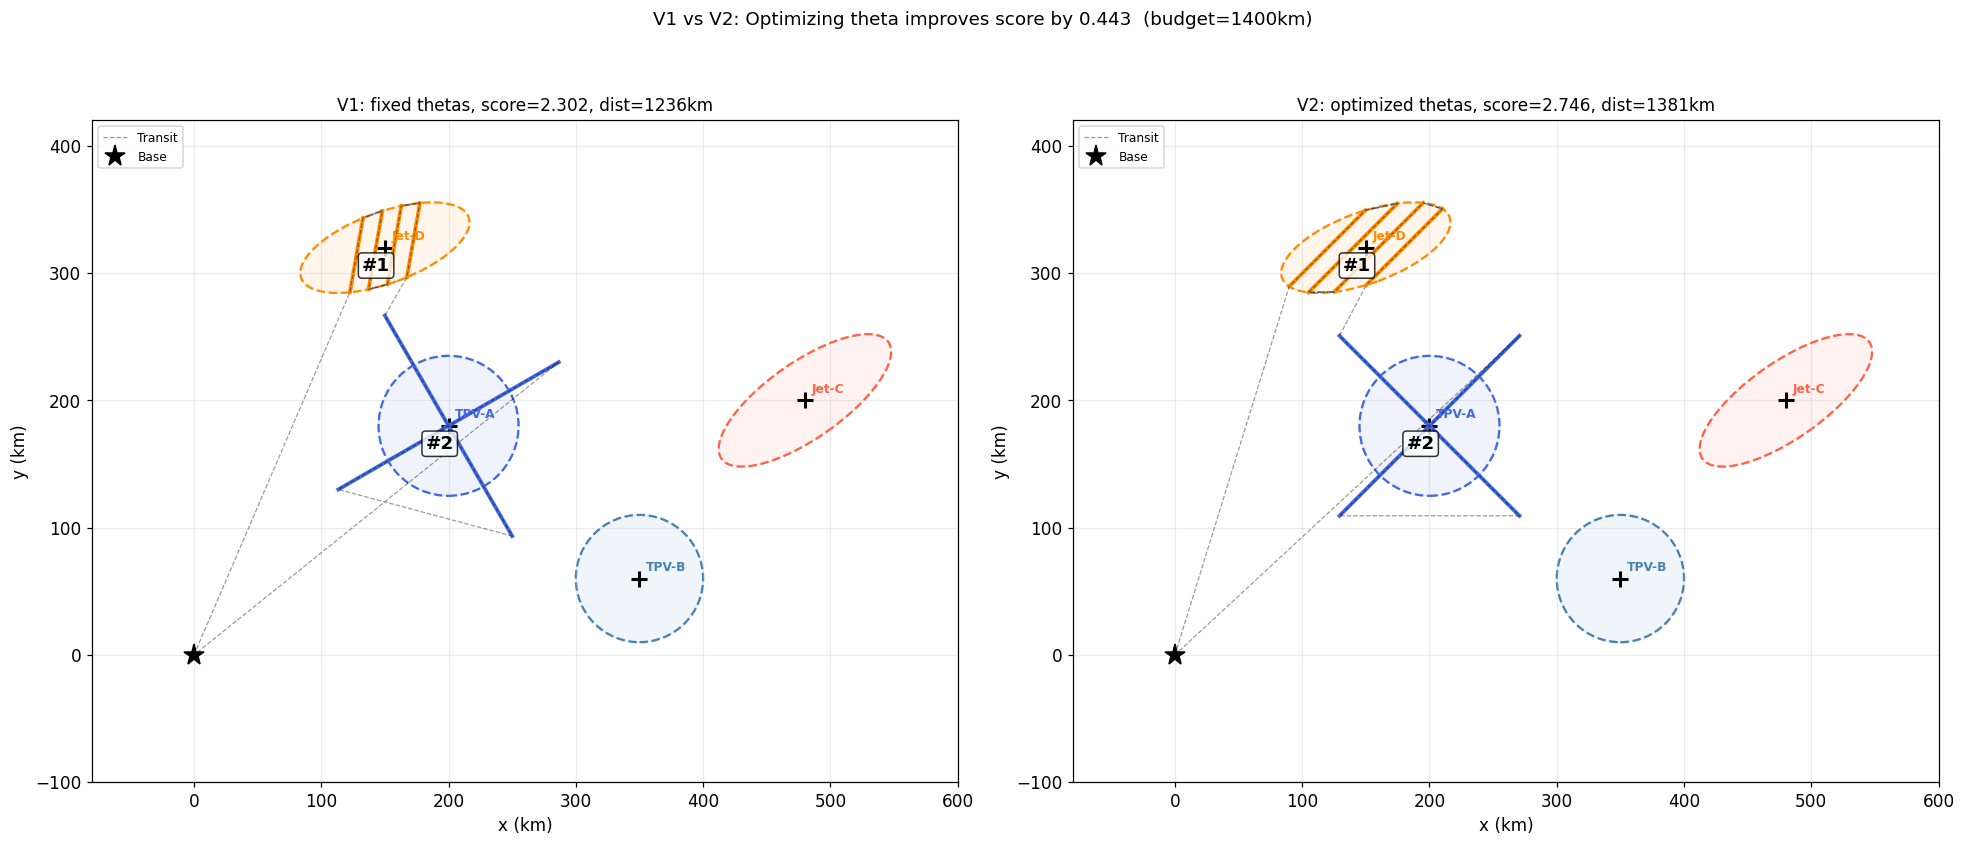

In [7]:
# ══════════════════════════════════════════════════════════════
# Compare V1 vs V2 route visualization
# ══════════════════════════════════════════════════════════════

def build_full_waypoints(order, cells_list, thetas, base):
    """Build the complete ordered waypoint list for a route."""
    wpts = [base.copy()]
    for idx in order:
        cell = cells_list[idx]
        th = thetas[cell.name]
        if isinstance(cell, CircularSupercell):
            legs = cell.leg_endpoints(th)
            # Choose entry: closest endpoint to current position
            last = wpts[-1]
            all_eps = [p for leg in legs for p in leg]
            best_entry = min(all_eps, key=lambda p: np.linalg.norm(p - last))
            # Fly: find which leg best_entry belongs to, start there
            for leg in legs:
                if any(np.allclose(best_entry, p) for p in leg):
                    ps, pe = leg
                    if np.allclose(best_entry, ps):
                        wpts += [ps.copy(), pe.copy()]
                    else:
                        wpts += [pe.copy(), ps.copy()]
                    break
            # Then fly the other leg
            for leg in legs:
                if not any(np.allclose(best_entry, p) for p in leg):
                    ps, pe = leg
                    last2 = wpts[-1]
                    if np.linalg.norm(last2-ps) <= np.linalg.norm(last2-pe):
                        wpts += [ps.copy(), pe.copy()]
                    else:
                        wpts += [pe.copy(), ps.copy()]
        else:
            bw = cell.boustrophedon_wpts(th)
            last = wpts[-1]
            if len(bw)>0 and np.linalg.norm(last-bw[-1]) < np.linalg.norm(last-bw[0]):
                bw = bw[::-1]
            wpts += bw
    wpts.append(base.copy())
    return wpts

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
colors_cell = ['royalblue', 'steelblue', 'tomato', 'darkorange']
titles = [f'V1: fixed thetas, score={best_score:.3f}, dist={best_dist:.0f}km',
          f'V2: optimized thetas, score={best_score_v2:.3f}, dist={best_dist_v2:.0f}km']
orders_plot = [best_order, best_order_v2]
thetas_plot = [THETAS_FIXED, best_thetas_v2]

for ax, order, thetas, title in zip(axes, orders_plot, thetas_plot, titles):
    # Draw supercell regions (use theta=0 for unvisited cells -- display only)
    for i, cell in enumerate(cells_v1):
        th = thetas.get(cell.name, 0.0)
        if isinstance(cell, CircularSupercell):
            ax.add_patch(plt.Circle(cell.center, cell.radius,
                                     color=colors_cell[i], alpha=0.08))
            ax.add_patch(plt.Circle(cell.center, cell.radius,
                                     fill=False, edgecolor=colors_cell[i], lw=1.5, ls='--'))
        else:
            ax.add_patch(Ellipse(cell.center, 2*cell.a, 2*cell.b,
                                  angle=np.degrees(cell.phi), color=colors_cell[i], alpha=0.08))
            ax.add_patch(Ellipse(cell.center, 2*cell.a, 2*cell.b,
                                  angle=np.degrees(cell.phi), fill=False,
                                  edgecolor=colors_cell[i], lw=1.5, ls='--'))
        ax.plot(*cell.center, 'k+', ms=10, mew=2)
        ax.text(*(cell.center+np.array([5,6])), cell.name, fontsize=8,
                color=colors_cell[i], fontweight='bold')

    # Draw observation legs for visited cells
    for rank, idx in enumerate(order):
        cell = cells_v1[idx]
        th = thetas[cell.name]
        col = colors_cell[idx]
        if isinstance(cell, CircularSupercell):
            for leg in cell.leg_endpoints(th):
                ps, pe = leg
                ax.plot([ps[0],pe[0]], [ps[1],pe[1]], color=col, lw=2.5)
        else:
            for leg in cell.leg_endpoints(th):
                ps, pe = leg
                ax.plot([ps[0],pe[0]], [ps[1],pe[1]], color=col, lw=2.5)
            wpts = cell.boustrophedon_wpts(th)
            for i in range(len(wpts)-1):
                if i%2==1:
                    ax.plot([wpts[i][0],wpts[i+1][0]], [wpts[i][1],wpts[i+1][1]],
                            color='gray', lw=1.2, ls='--')

    # Draw full route
    wpts_full = np.array(build_full_waypoints(order, cells_v1, thetas, BASE))
    ax.plot(wpts_full[:,0], wpts_full[:,1], 'k--', lw=0.8, alpha=0.4, label='Transit')

    # Number the visit order
    for rank, idx in enumerate(order):
        cell = cells_v1[idx]
        ax.text(*(cell.center+np.array([-18,-18])), f'#{rank+1}',
                fontsize=12, color='black', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    # Base
    ax.plot(*BASE, '*k', ms=14, zorder=7, label='Base')
    ax.set_xlim(-80, 600); ax.set_ylim(-100, 420)
    ax.set_aspect('equal')
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle(f'V1 vs V2: Optimizing theta improves score by '
             f'{best_score_v2-best_score:.3f}  (budget={BUDGET_KM:.0f}km)',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/v1_vs_v2_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


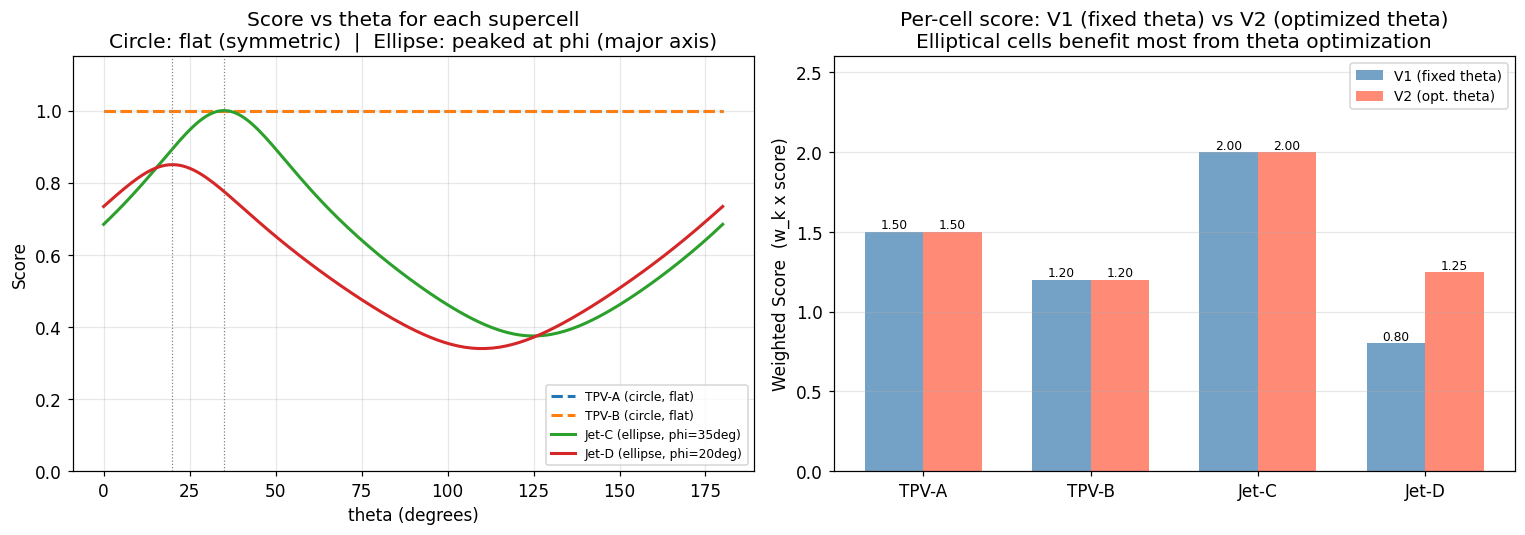

In [8]:
# ══════════════════════════════════════════════════════════════
# Show score sensitivity to theta for each supercell type
# ══════════════════════════════════════════════════════════════

thetas_deg = np.linspace(0, 180, 181)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: circular (flat) vs elliptical (peaked)
ax = axes[0]
for cell in cells_v1:
    if isinstance(cell, CircularSupercell):
        scores = [score_circular(cell, np.radians(t)) for t in thetas_deg]
        ax.plot(thetas_deg, scores, lw=2, ls='--', label=f'{cell.name} (circle, flat)')
    else:
        scores = [score_elliptical(cell, np.radians(t))['total'] for t in thetas_deg]
        ax.plot(thetas_deg, scores, lw=2, label=f'{cell.name} (ellipse, phi={np.degrees(cell.phi):.0f}deg)')
        ax.axvline(np.degrees(cell.phi), color='gray', lw=0.8, ls=':')

ax.set_xlabel('theta (degrees)'); ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Score vs theta for each supercell\n'
             'Circle: flat (symmetric)  |  Ellipse: peaked at phi (major axis)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Right: v1 (fixed theta) vs v2 (optimized theta) scores per cell
ax2 = axes[1]
cell_names = [c.name for c in cells_v1]
v1_sc = [c.weight * (score_circular(c, THETAS_FIXED[c.name])
          if isinstance(c, CircularSupercell)
          else score_elliptical(c, THETAS_FIXED[c.name])['total'])
         for c in cells_v1]
v2_sc = [c.weight * (score_circular(c, best_thetas_v2.get(c.name, THETAS_FIXED[c.name]))
          if isinstance(c, CircularSupercell)
          else score_elliptical(c, best_thetas_v2.get(c.name, THETAS_FIXED[c.name]))['total'])
         for c in cells_v1]

x = np.arange(len(cell_names))
w = 0.35
bars1 = ax2.bar(x - w/2, v1_sc, w, label='V1 (fixed theta)', color='steelblue', alpha=0.75)
bars2 = ax2.bar(x + w/2, v2_sc, w, label='V2 (opt. theta)',  color='tomato', alpha=0.75)
for bar, val in zip(list(bars1)+list(bars2), v1_sc+v2_sc):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.2f}', ha='center', fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels(cell_names)
ax2.set_ylabel('Weighted Score  (w_k x score)')
ax2.set_title('Per-cell score: V1 (fixed theta) vs V2 (optimized theta)\n'
              'Elliptical cells benefit most from theta optimization')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, max(v1_sc+v2_sc)*1.3)

plt.tight_layout()
plt.savefig('figures/score_v1_v2_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 5. Summary: What Each Version Optimizes

```
Given (always fixed):   q_k, radius/a/b/phi, weight  for each supercell

V1 (Orienteering OP):
  Fixed:    theta, L (circle), m, s (ellipse)
  Optimize: which cells to visit (x_k) + visit order (sigma)
  Problem:  standard Orienteering Problem (OP/OPTW)
  Solver:   MILP (small N) or ALNS (large N)

V2 (OP + direction):
  Fixed:    L, m, s
  Optimize: x_k, sigma, AND theta_k in {0,15,...,165} for each cell
  Impact:   elliptical cells benefit most (score peaks at phi)
            circular cells: theta affects inter-cell cost (entry/exit point)
  Solver:   MILP with theta indexed variables, or ALNS with theta in local search

V3 (Full):
  Fixed:    nothing (beyond the supercell geometry inputs)
  Optimize: x_k, sigma, theta_k, L_k (circle), m_k, s_k (ellipse)
  Notes:    L/m/s trade off internal pattern distance vs score quality
            E.g. more legs (m) = better ellipse coverage but more internal flight time
  Solver:   ALNS with full parameter search, or MILP with discretized L/m/s
```

**Next notebook**: `02_milp_v1.ipynb` -- implement V1 as a proper MILP using PuLP/Gurobi.
